# NB02e — Retrieval Comparison and Three-Way Forensic EDA

This notebook does two things:

1. compares retrieval behaviour on the unified `restaurants` LanceDB table across    FTS-only, vector-only, and hybrid modes
2. builds a three-way competitive baseline across Italian, American (New), and Mexican    restaurants/reviews in Philadelphia and Tampa

**Why combine them?** Both analyses depend on the same post-NB01c three-cuisine corpus, and it is cleaner to inspect retrieval quality and competitive landscape together.

| Figure | Description |
|---|---|
| `fig15_retrieval_alignment.png` | Heuristic retrieval alignment@5 by mode and query family |
| `fig16_three_way_rating_distribution.png` | Rating distribution by cuisine |
| `fig17_three_way_price_tier.png` | Price tier distribution by cuisine |
| `fig18_three_way_vader_sentiment.png` | VADER sentiment comparison by cuisine |
| `fig19_three_way_volume_over_time.png` | Monthly review volume by cuisine |

Run cells top-to-bottom. Inspect each output before moving on.

## 1. Environment setup

Imports, project-root resolution, output directory creation, and the libraries needed for retrieval comparison plus three-way EDA.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.auto import tqdm
import lancedb
from lancedb.rerankers import RRFReranker
from llama_cpp import Llama

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), f"Cannot find project root from {Path().resolve()}"

PROCESSED = ROOT / "data" / "processed"
DB_PATH   = ROOT / "data" / "lancedb"
FIG_DIR   = ROOT / "outputs" / "figures" / "nb02e"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print(f"Project root : {ROOT}")
print(f"DB path      : {DB_PATH}")
print(f"Figures dir  : {FIG_DIR}")

Project root : /home/endy/menuforge
DB path      : /home/endy/menuforge/data/lancedb
Figures dir  : /home/endy/menuforge/outputs/figures/nb02e


## 2. Build the unified three-cuisine restaurant and review frames

Italian data is loaded from the original NB01 outputs and tagged with `cuisine_type = italian`. American (New) and Mexican come from the comparison parquets built in NB01c. This cell is the single source of truth for the EDA half of the notebook.

In [2]:
italian_rest = pd.read_parquet(PROCESSED / "restaurants.parquet").copy()
italian_rest["cuisine_type"] = "italian"

comparison_rest = pd.read_parquet(PROCESSED / "comparison_restaurants.parquet").copy()

italian_rev = pd.read_parquet(PROCESSED / "reviews.parquet").copy()
italian_rev["cuisine_type"] = "italian"

comparison_rev = pd.read_parquet(PROCESSED / "comparison_reviews.parquet").copy()

rest_cols = sorted(set(italian_rest.columns).union(comparison_rest.columns))
rev_cols  = sorted(set(italian_rev.columns).union(comparison_rev.columns))

restaurants_all = pd.concat(
    [italian_rest.reindex(columns=rest_cols), comparison_rest.reindex(columns=rest_cols)],
    ignore_index=True,
)
reviews_all = pd.concat(
    [italian_rev.reindex(columns=rev_cols), comparison_rev.reindex(columns=rev_cols)],
    ignore_index=True,
)

reviews_all["date"] = pd.to_datetime(reviews_all["date"], errors="coerce")
restaurants_all["price"] = pd.to_numeric(restaurants_all["price_range"], errors="coerce")

CUISINE_ORDER = ["italian", "american_new", "mexican"]
CUISINE_LABELS = {
    "italian": "Italian",
    "american_new": "American (New)",
    "mexican": "Mexican",
}

print("Restaurants:")
print(restaurants_all["cuisine_type"].value_counts().reindex(CUISINE_ORDER).to_string())
print()
print("Reviews:")
print(reviews_all["cuisine_type"].value_counts().reindex(CUISINE_ORDER).to_string())
print()
print("Cities by cuisine:")
print(restaurants_all.groupby(["cuisine_type", "city"]).size().to_string())

Restaurants:
cuisine_type
italian          717
american_new    1099
mexican          522

Reviews:
cuisine_type
italian         105774
american_new    113265
mexican          39201

Cities by cuisine:
cuisine_type  city        
american_new  Philadelphia    751
              Tampa           348
italian       Philadelphia    505
              Tampa           212
mexican       Philadelphia    302
              Tampa           220


## 3. Unified corpus gate checks

Quick verification before retrieval or plotting. This confirms the three-cuisine merge matches the post-NB01c expectations.

In [3]:
checks = {
    "italian restaurants >= 700":      (restaurants_all["cuisine_type"] == "italian").sum() >= 700,
    "american_new restaurants >= 900": (restaurants_all["cuisine_type"] == "american_new").sum() >= 900,
    "mexican restaurants >= 400":      (restaurants_all["cuisine_type"] == "mexican").sum() >= 400,
    "italian reviews >= 100000":       (reviews_all["cuisine_type"] == "italian").sum() >= 100_000,
    "american_new reviews >= 100000":  (reviews_all["cuisine_type"] == "american_new").sum() >= 100_000,
    "mexican reviews >= 39000":        (reviews_all["cuisine_type"] == "mexican").sum() >= 39_000,
}

print("Unified corpus gates:")
for label, ok in checks.items():
    print(f"  {label:<32} [{'OK' if ok else 'CHECK'}]")

Unified corpus gates:
  italian restaurants >= 700       [OK]
  american_new restaurants >= 900  [OK]
  mexican restaurants >= 400       [OK]
  italian reviews >= 100000        [OK]
  american_new reviews >= 100000   [OK]
  mexican reviews >= 39000         [OK]


## 4. Connect to LanceDB and load the embedding model

The retrieval comparison uses the unified `restaurants` table created in NB01c. We also load the small embedding model so we can compare vector-only and hybrid retrieval against FTS-only on the same query set.

In [4]:
MODEL_PATH = ROOT / "models" / "embeddinggemma-300M-BF16.gguf"
assert MODEL_PATH.exists(), f"Embedding model not found: {MODEL_PATH}"

db = lancedb.connect(str(DB_PATH))
assert "restaurants" in db.table_names(), "Unified 'restaurants' table not found — finish NB01c first."

tbl_restaurants = db.open_table("restaurants")
reranker = RRFReranker()

print("Loading embedding model...")
embedder = Llama(
    model_path=str(MODEL_PATH),
    embedding=True,
    n_ctx=512,
    n_gpu_layers=-1,
    verbose=False,
)

probe = embedder.embed("retrieval probe")
print(f"Embedding dimension : {len(probe)}")
print(f"Available tables    : {db.table_names()}")

/tmp/ipykernel_231496/512487115.py:5: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  assert "restaurants" in db.table_names(), "Unified 'restaurants' table not found — finish NB01c first."


Loading embedding model...


llama_context: n_ctx_seq (512) < n_ctx_train (2048) -- the full capacity of the model will not be utilized
init: embeddings required but some input tokens were not marked as outputs -> overriding


Embedding dimension : 768
Available tables    : ['american_menus', 'menu_items', 'nypl_menus', 'restaurants', 'reviews']


/tmp/ipykernel_231496/512487115.py:21: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  print(f"Available tables    : {db.table_names()}")


## 5. Build the retrieval query bank

The query bank combines:

- **named_entity** queries built from actual high-review restaurants in the corpus
- **semantic** queries that describe cuisine/city intent without naming a restaurant
- **mixed** queries that combine a real restaurant name with cuisine/city context

This keeps the retrieval test grounded in the current dataset rather than in assumed restaurant names.

In [5]:
def choose_top_name(df, cuisine, city):
    row = (
        df[(df["cuisine_type"] == cuisine) & (df["city"] == city)]
        .sort_values(["review_count", "stars"], ascending=[False, False])
        .iloc[0]
    )
    return row["name"]


query_specs = []

SHOWCASE_NAMES = {
    ("italian", "Philadelphia"): "Barbuzzo",
    ("italian", "Tampa"): "Maggiano's Little Italy",
    ("american_new", "Philadelphia"): "Parc",
    ("american_new", "Tampa"): "Datz",
    ("mexican", "Philadelphia"): "El Vez",
    ("mexican", "Tampa"): "Lolis Mexican Cravings",
}

# Named-entity queries: exact restaurant-name lookups
for cuisine, city in [
    ("italian", "Philadelphia"),
    ("italian", "Tampa"),
    ("american_new", "Philadelphia"),
    ("american_new", "Tampa"),
    ("mexican", "Philadelphia"),
    ("mexican", "Tampa"),
]:
    name = SHOWCASE_NAMES.get((cuisine, city), choose_top_name(restaurants_all, cuisine, city))
    query_specs.append({
        "query_text": name,
        "query_family": "named_entity",
        "cuisine_scope": cuisine,
        "city_scope": city,
        "expected_name": name,
    })

# Semantic queries: no exact restaurant name, only intent/scoping terms
for query_text, cuisine, city in [
    ("Italian restaurants Philadelphia", "italian", "Philadelphia"),
    ("Italian restaurants Tampa", "italian", "Tampa"),
    ("American New restaurants Philadelphia", "american_new", "Philadelphia"),
    ("American New restaurants Tampa", "american_new", "Tampa"),
    ("Mexican restaurants Philadelphia", "mexican", "Philadelphia"),
    ("Mexican restaurants Tampa", "mexican", "Tampa"),
]:
    query_specs.append({
        "query_text": query_text,
        "query_family": "semantic",
        "cuisine_scope": cuisine,
        "city_scope": city,
        "expected_name": None,
    })

# Mixed queries: real restaurant + extra contextual words
for cuisine, city in [
    ("italian", "Philadelphia"),
    ("italian", "Tampa"),
    ("american_new", "Philadelphia"),
    ("american_new", "Tampa"),
    ("mexican", "Philadelphia"),
    ("mexican", "Tampa"),
]:
    name = SHOWCASE_NAMES.get((cuisine, city), choose_top_name(restaurants_all, cuisine, city))
    label = CUISINE_LABELS[cuisine]
    query_specs.append({
        "query_text": f"{name} {label} {city}",
        "query_family": "mixed",
        "cuisine_scope": cuisine,
        "city_scope": city,
        "expected_name": name,
    })

query_bank = pd.DataFrame(query_specs)
print(query_bank.to_string(index=False))

                           query_text query_family cuisine_scope   city_scope           expected_name
                             Barbuzzo named_entity       italian Philadelphia                Barbuzzo
              Maggiano's Little Italy named_entity       italian        Tampa Maggiano's Little Italy
                                 Parc named_entity  american_new Philadelphia                    Parc
                                 Datz named_entity  american_new        Tampa                    Datz
                               El Vez named_entity       mexican Philadelphia                  El Vez
               Lolis Mexican Cravings named_entity       mexican        Tampa  Lolis Mexican Cravings
     Italian restaurants Philadelphia     semantic       italian Philadelphia                    None
            Italian restaurants Tampa     semantic       italian        Tampa                    None
American New restaurants Philadelphia     semantic  american_new Philadelphia     

## 6. Retrieval helpers and heuristic scoring

The notebook uses a deliberately honest scoring proxy called **alignment@5** rather than claiming true precision@5. Alignment rewards the top-5 results for matching the expected cuisine, city, and (for named/mixed queries) the target restaurant name.

This gives us a fast comparative signal while still leaving room for later manual spot-checking if needed.

In [6]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return " ".join(text.split())


def run_retrieval(mode, query_text, cuisine_scope=None):
    query_vec = embedder.embed(query_text)

    if mode == "fts":
        q = tbl_restaurants.search(query_text, query_type="fts")
    elif mode == "vector":
        q = tbl_restaurants.search(query_vec, query_type="vector")
    elif mode == "hybrid":
        q = (
            tbl_restaurants.search(query_type="hybrid")
            .vector(query_vec)
            .text(query_text)
            .rerank(reranker)
        )
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if cuisine_scope:
        q = q.where(f"cuisine_type = '{cuisine_scope}'", prefilter=True)

    return q.limit(5).to_pandas()


def alignment_score(row, spec):
    points = 0
    max_points = 0

    if spec["cuisine_scope"]:
        max_points += 1
        if row["cuisine_type"] == spec["cuisine_scope"]:
            points += 1

    if spec["city_scope"]:
        max_points += 1
        if row["city"] == spec["city_scope"]:
            points += 1

    if spec["expected_name"]:
        max_points += 2
        if normalize_text(spec["expected_name"]) == normalize_text(row["name"]):
            points += 2

    return points / max_points if max_points else np.nan


## 7. Run retrieval comparison across all queries

For each query in the bank, the notebook runs:

- FTS-only
- vector-only
- hybrid (FTS + vector + RRF)

It then computes `alignment@5` for the top-5 rows and saves a detailed audit table.

In [7]:
records = []
audit_rows = []

for spec in tqdm(query_bank.to_dict("records"), desc="Retrieval queries", unit="query"):
    for mode in ["fts", "vector", "hybrid"]:
        res = run_retrieval(mode, spec["query_text"], cuisine_scope=spec["cuisine_scope"])

        if len(res) == 0:
            records.append({
                "query_text": spec["query_text"],
                "query_family": spec["query_family"],
                "mode": mode,
                "alignment_at_5": 0.0,
                "n_results": 0,
            })
            continue

        res = res.copy()
        res["alignment"] = res.apply(lambda row: alignment_score(row, spec), axis=1)

        for rank, row in enumerate(res.itertuples(index=False), start=1):
            audit_rows.append({
                "query_text": spec["query_text"],
                "query_family": spec["query_family"],
                "mode": mode,
                "rank": rank,
                "name": row.name,
                "city": row.city,
                "cuisine_type": row.cuisine_type,
                "stars": row.stars,
                "alignment": row.alignment,
            })

        records.append({
            "query_text": spec["query_text"],
            "query_family": spec["query_family"],
            "mode": mode,
            "alignment_at_5": res["alignment"].mean(),
            "n_results": len(res),
        })

retrieval_summary = pd.DataFrame(records)
retrieval_audit   = pd.DataFrame(audit_rows)

retrieval_audit.to_csv(FIG_DIR / "retrieval_audit_table.csv", index=False)

print(retrieval_summary.groupby(["query_family", "mode"])["alignment_at_5"].mean().round(3).to_string())
print()
print(f"Audit table written: {(FIG_DIR / 'retrieval_audit_table.csv').relative_to(ROOT)}")

Retrieval queries:   0%|          | 0/18 [00:00<?, ?query/s]

init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings requ

query_family  mode  
mixed         fts       0.600
              hybrid    0.650
              vector    0.617
named_entity  fts       0.825
              hybrid    0.542
              vector    0.492
semantic      fts       0.800
              hybrid    0.933
              vector    1.000

Audit table written: outputs/figures/nb02e/retrieval_audit_table.csv


## 8. Figure 15 — Retrieval alignment by mode and query family

This figure summarises the average `alignment@5` score by retrieval mode within each query family. Higher is better, but remember this is a heuristic alignment proxy rather than a manually judged precision score.

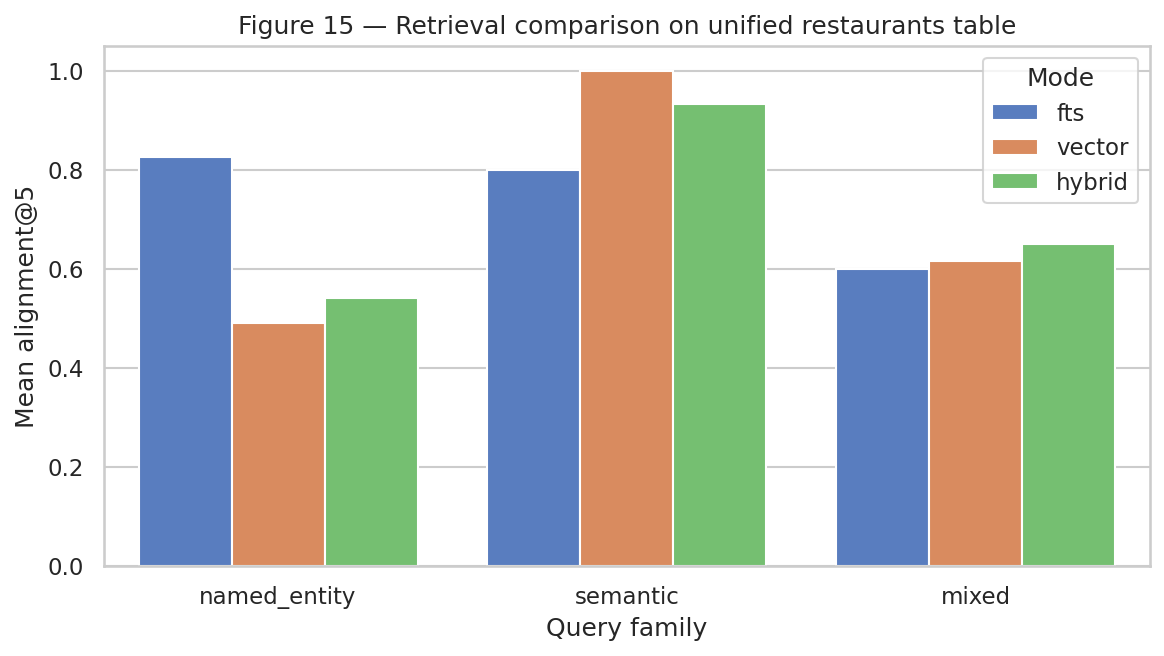

Saved: outputs/figures/nb02e/fig15_retrieval_alignment.png

Sample retrieval rows:
             query_text query_family   mode  rank                    name         city cuisine_type  stars  alignment
               Barbuzzo named_entity    fts     1                Barbuzzo Philadelphia      italian    4.5       1.00
               Barbuzzo named_entity vector     1                Barbuzzo Philadelphia      italian    4.5       1.00
               Barbuzzo named_entity vector     2                  Sbarro Philadelphia      italian    3.0       0.50
               Barbuzzo named_entity vector     3      Barrel's Fine Food Philadelphia      italian    4.0       0.50
               Barbuzzo named_entity vector     4                  Sbarro        Tampa      italian    3.5       0.25
               Barbuzzo named_entity vector     5                  Sbarro        Tampa      italian    2.5       0.25
               Barbuzzo named_entity hybrid     1                Barbuzzo Philadelphia     

In [8]:
plot_df = (
    retrieval_summary.groupby(["query_family", "mode"], as_index=False)["alignment_at_5"]
    .mean()
)

mode_order = ["fts", "vector", "hybrid"]
family_order = ["named_entity", "semantic", "mixed"]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=plot_df,
    x="query_family",
    y="alignment_at_5",
    hue="mode",
    order=family_order,
    hue_order=mode_order,
    ax=ax,
)
ax.set_xlabel("Query family")
ax.set_ylabel("Mean alignment@5")
ax.set_title("Figure 15 — Retrieval comparison on unified restaurants table")
ax.set_ylim(0, 1.05)
ax.legend(title="Mode")

out = FIG_DIR / "fig15_retrieval_alignment.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")
print()
print("Sample retrieval rows:")
print(retrieval_audit.head(12).to_string(index=False))

## 9. Compute VADER sentiment for the three-way review corpus

This is the slowest CPU-only step in the notebook. It scores all reviews across the three cuisines using VADER so we can compare sentiment at corpus scale without adding a second LLM inference path.

In [9]:
sia = SentimentIntensityAnalyzer()
tqdm.pandas(desc="VADER")
reviews_all["vader"] = reviews_all["text"].fillna("").progress_apply(
    lambda t: sia.polarity_scores(t)["compound"]
)

print("VADER done.")
print(reviews_all.groupby("cuisine_type")["vader"].agg(["median", "mean"]).round(3).to_string())

VADER:   0%|          | 0/258240 [00:00<?, ?it/s]

VADER done.
              median   mean
cuisine_type               
american_new   0.934  0.694
italian        0.932  0.704
mexican        0.909  0.626


## 10. Figure 16 — Rating distribution by cuisine

Box plots compare restaurant star ratings across Italian, American (New), and Mexican. This is the first part of the three-way competitive landscape baseline.

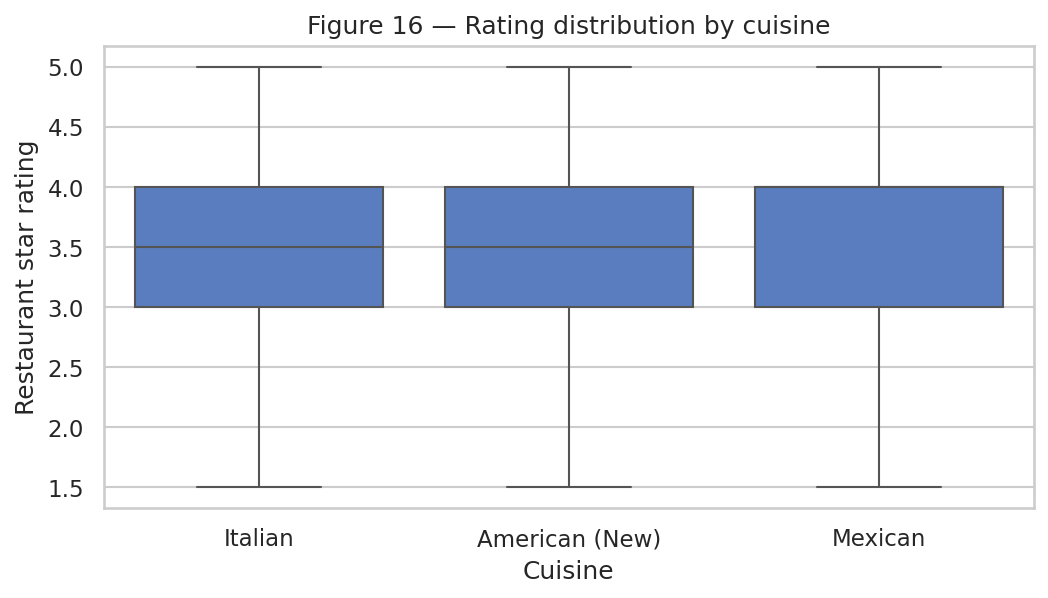

Saved: outputs/figures/nb02e/fig16_three_way_rating_distribution.png


In [10]:
plot_rest = restaurants_all.copy()
plot_rest["Cuisine"] = plot_rest["cuisine_type"].map(CUISINE_LABELS)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=plot_rest,
    x="Cuisine",
    y="stars",
    order=[CUISINE_LABELS[c] for c in CUISINE_ORDER],
    showfliers=False,
    ax=ax,
)
ax.set_xlabel("Cuisine")
ax.set_ylabel("Restaurant star rating")
ax.set_title("Figure 16 — Rating distribution by cuisine")

out = FIG_DIR / "fig16_three_way_rating_distribution.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")

## 11. Figure 17 — Price tier distribution by cuisine

Stacked percentage bars compare Yelp price tiers across the three cuisines. This is a compact proxy for competitive positioning and expected spend level.

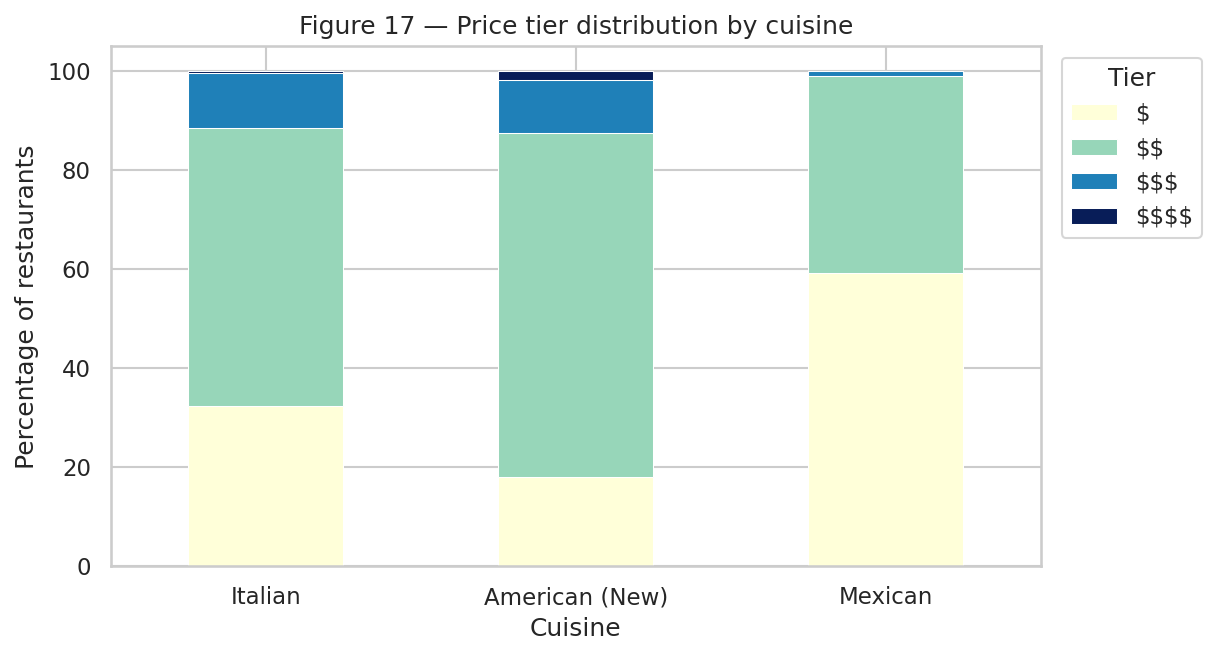

Saved: outputs/figures/nb02e/fig17_three_way_price_tier.png

Count table:
tier             \$  \$\$  \$\$\$  \$\$\$\$
Cuisine                                    
Italian         200   349      68         3
American (New)  179   697     107        19
Mexican         234   157       4         0


In [12]:
priced = restaurants_all.dropna(subset=["price"]).copy()
priced["price"] = priced["price"].astype(int)
priced["Cuisine"] = priced["cuisine_type"].map(CUISINE_LABELS)
price_labels = {1: "\\$", 2: "\\$\\$", 3: "\\$\\$\\$", 4: "\\$\\$\\$\\$"}

priced["tier"] = priced["price"].map(price_labels)

pivot = (
    priced.groupby(["Cuisine", "tier"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=[CUISINE_LABELS[c] for c in CUISINE_ORDER], fill_value=0)
    .reindex(columns=["\\$", "\\$\\$", "\\$\\$\\$", "\\$\\$\\$\\$"], fill_value=0)

)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
pct.plot(kind="bar", stacked=True, ax=ax, colormap="YlGnBu", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Cuisine")
ax.set_ylabel("Percentage of restaurants")
ax.set_title("Figure 17 — Price tier distribution by cuisine")
ax.set_xticklabels(pct.index, rotation=0)
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1), loc="upper left")

out = FIG_DIR / "fig17_three_way_price_tier.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")
print()
print("Count table:")
print(pivot.to_string())

## 12. Figure 18 — VADER sentiment comparison by cuisine

This figure compares review-level VADER distributions across the three cuisines. It is not a substitute for human evaluation, but it is a useful sentiment baseline for the horizon scan's competitive landscape section.

/tmp/ipykernel_231496/698830822.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 12000), random_state=42))


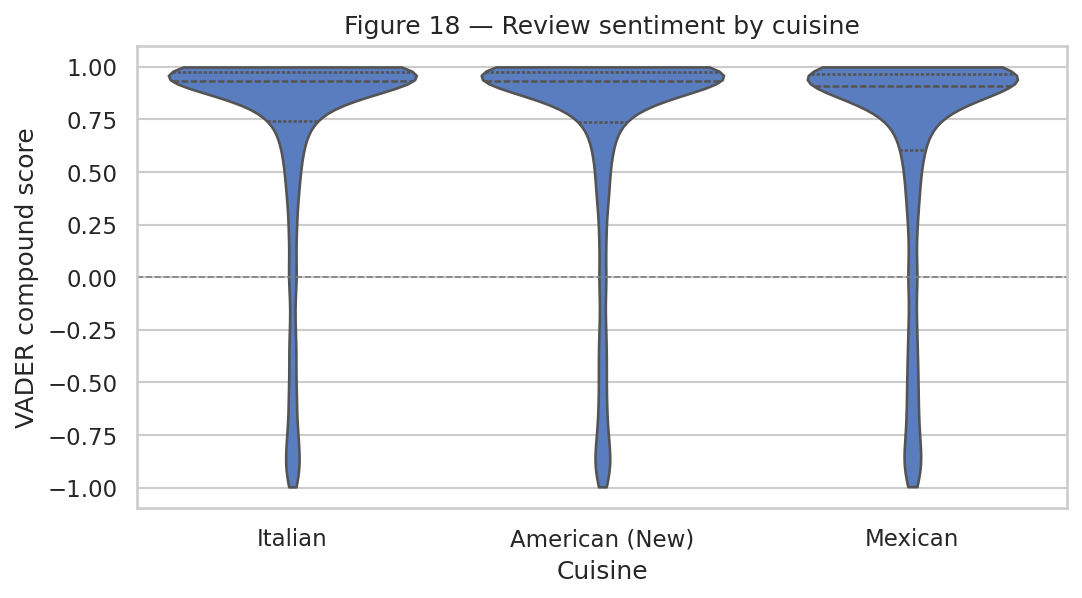

Saved: outputs/figures/nb02e/fig18_three_way_vader_sentiment.png

                median   mean
Cuisine                      
American (New)   0.934  0.694
Italian          0.932  0.704
Mexican          0.909  0.626


In [13]:
plot_rev = reviews_all.copy()
plot_rev["Cuisine"] = plot_rev["cuisine_type"].map(CUISINE_LABELS)

sampled = (
    plot_rev.groupby("Cuisine", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 12000), random_state=42))
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=sampled,
    x="Cuisine",
    y="vader",
    order=[CUISINE_LABELS[c] for c in CUISINE_ORDER],
    cut=0,
    inner="quartile",
    ax=ax,
)
ax.set_xlabel("Cuisine")
ax.set_ylabel("VADER compound score")
ax.set_title("Figure 18 — Review sentiment by cuisine")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)

out = FIG_DIR / "fig18_three_way_vader_sentiment.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")
print()
print(plot_rev.groupby("Cuisine")["vader"].agg(["median", "mean"]).round(3).to_string())

## 13. Figure 19 — Monthly review volume by cuisine

Monthly review counts show how the three cuisines evolve over time and whether the COVID-era disruption appears similarly across the competitive set.

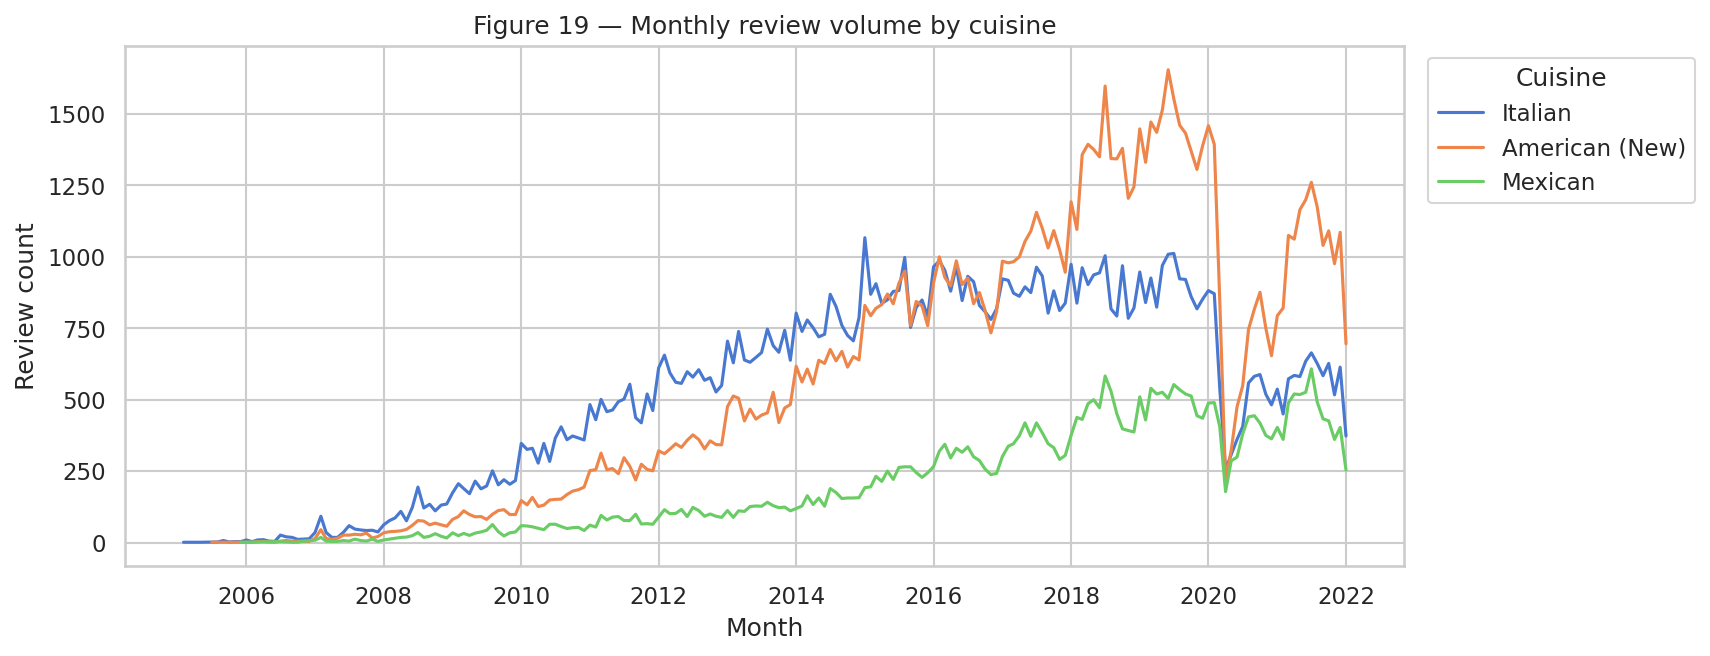

Saved: outputs/figures/nb02e/fig19_three_way_volume_over_time.png


In [14]:
volume = (
    reviews_all.dropna(subset=["date"])
    .assign(month=lambda df: df["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "cuisine_type"])
    .size()
    .reset_index(name="count")
)
volume["Cuisine"] = volume["cuisine_type"].map(CUISINE_LABELS)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(
    data=volume,
    x="month",
    y="count",
    hue="Cuisine",
    hue_order=[CUISINE_LABELS[c] for c in CUISINE_ORDER],
    ax=ax,
)
ax.set_xlabel("Month")
ax.set_ylabel("Review count")
ax.set_title("Figure 19 — Monthly review volume by cuisine")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(title="Cuisine", bbox_to_anchor=(1.01, 1), loc="upper left")

out = FIG_DIR / "fig19_three_way_volume_over_time.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")

## 14. One-star TF-IDF bigrams by cuisine

This section surfaces what dissatisfied reviewers complain about most in each cuisine. It is kept as a printed comparative table rather than another figure to avoid clutter.

In [15]:
def top_bigrams(texts, n=10):
    vec = TfidfVectorizer(
        ngram_range=(2, 2),
        stop_words="english",
        max_features=10000,
        min_df=5,
        strip_accents="unicode",
    )
    X = vec.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    idx = scores.argsort()[::-1][:n]
    return [(terms[i], float(scores[i])) for i in idx]


rows = []
for cuisine in CUISINE_ORDER:
    texts = reviews_all.loc[
        (reviews_all["cuisine_type"] == cuisine) & (reviews_all["stars"] == 1.0),
        "text"
    ].fillna("").tolist()
    for term, score in top_bigrams(texts, n=10):
        rows.append({
            "Cuisine": CUISINE_LABELS[cuisine],
            "bigram": term,
            "score": round(score, 6),
        })

bigrams_df = pd.DataFrame(rows)
bigrams_df.to_csv(FIG_DIR / "three_way_one_star_bigrams.csv", index=False)

print(bigrams_df.groupby("Cuisine").head(10).to_string(index=False))
print()
print(f"Saved: {(FIG_DIR / 'three_way_one_star_bigrams.csv').relative_to(ROOT)}")

       Cuisine           bigram    score
       Italian customer service 0.010841
       Italian      tasted like 0.006751
       Italian        food good 0.006064
       Italian         don know 0.005283
       Italian     cheese steak 0.005149
       Italian       20 minutes 0.005054
       Italian       waste time 0.004616
       Italian       10 minutes 0.004567
       Italian       30 minutes 0.004535
       Italian       15 minutes 0.004502
American (New) customer service 0.009515
American (New)       20 minutes 0.006379
American (New)      tasted like 0.006307
American (New)       15 minutes 0.005760
American (New)       10 minutes 0.005508
American (New)       30 minutes 0.005504
American (New)       happy hour 0.005034
American (New)        food good 0.004996
American (New)         don know 0.004836
American (New)    minutes later 0.004537
       Mexican        taco bell 0.016225
       Mexican     mexican food 0.012421
       Mexican customer service 0.012387
       Mexican  

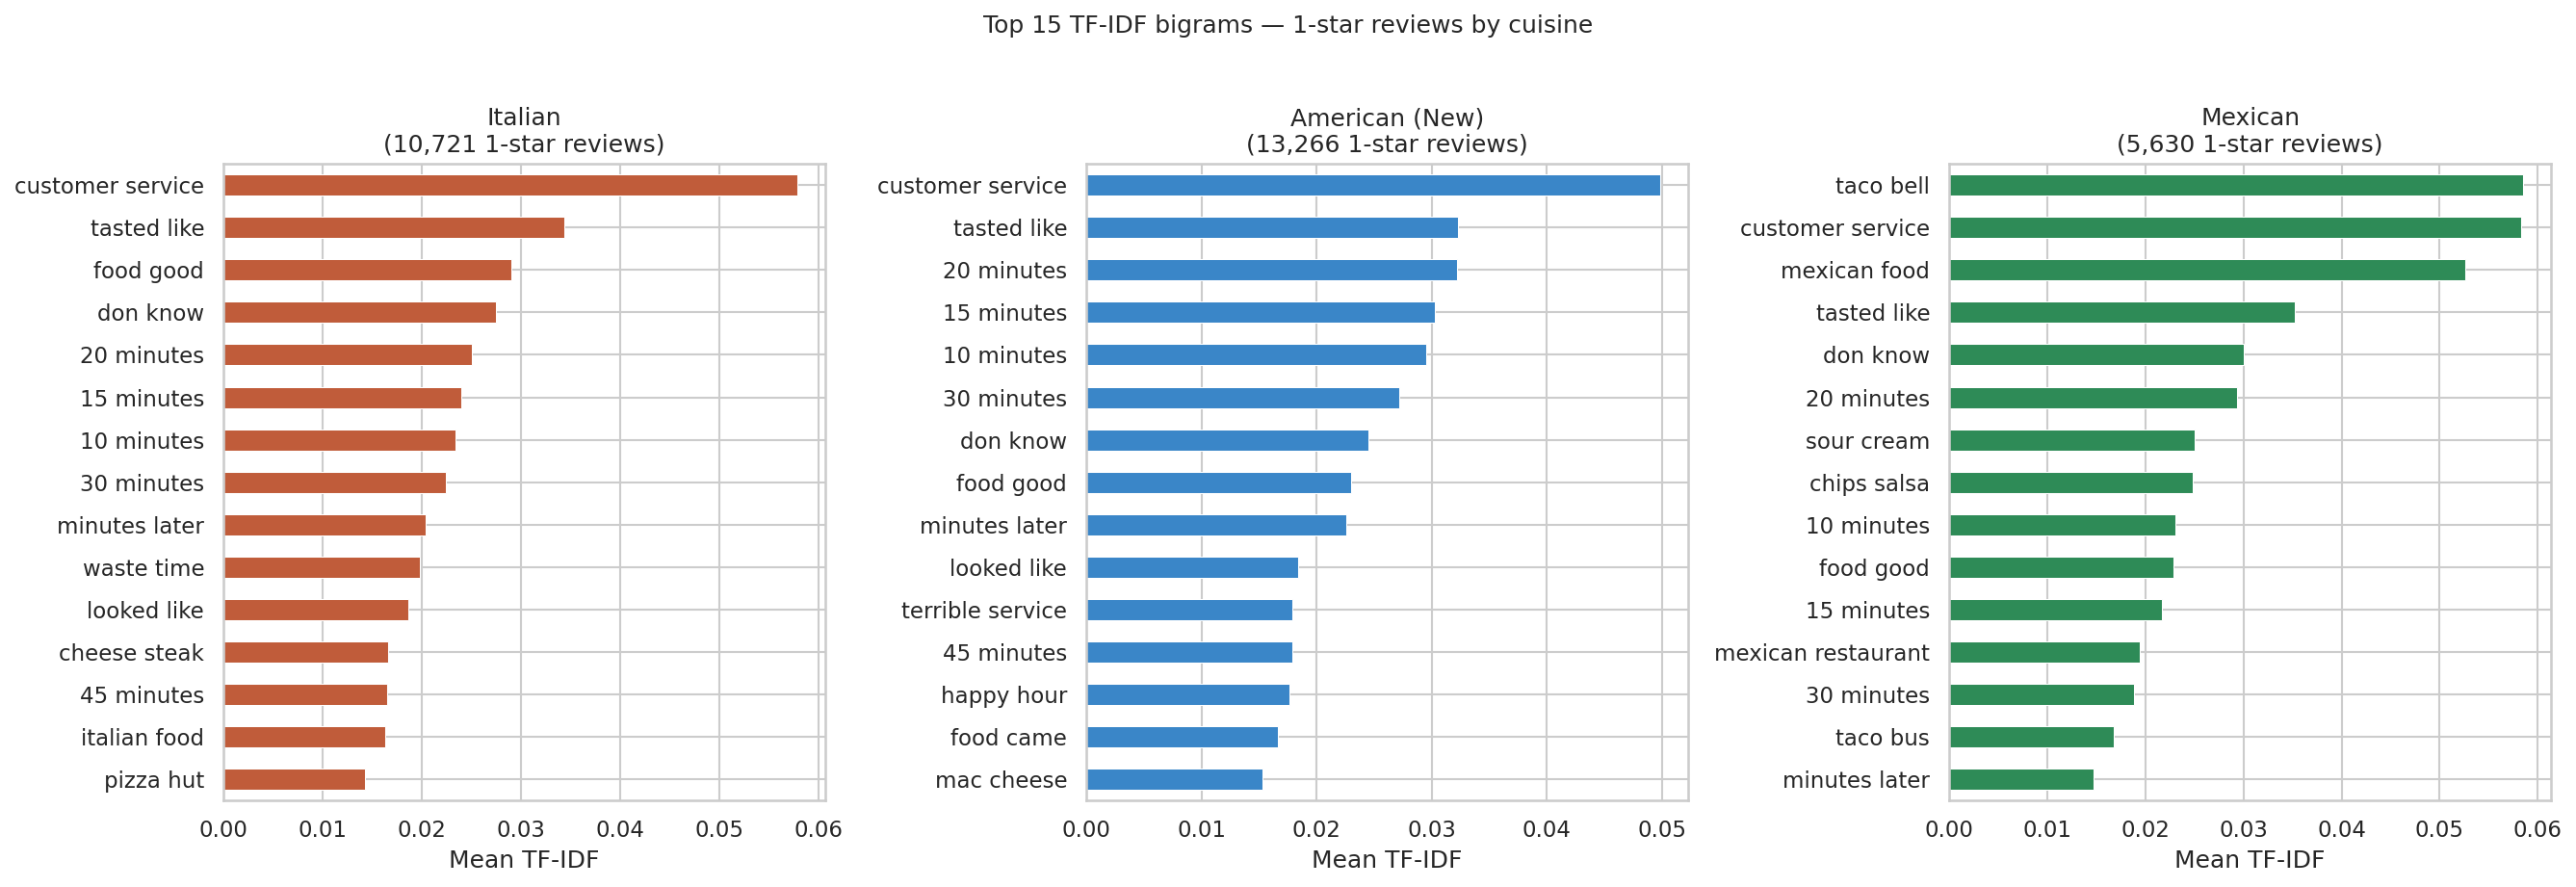

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

cuisine_colors = {"italian": "#c05c3a", "american_new": "#3A86C8", "mexican": "#2E8B57"}

for ax, cuisine in zip(axes, CUISINE_ORDER):
    texts = reviews_all[
        (reviews_all["stars"] == 1) & (reviews_all["cuisine_type"] == cuisine)
    ]["text"].fillna("").values

    tfidf = TfidfVectorizer(ngram_range=(2, 2), max_features=15, stop_words="english")
    X = tfidf.fit_transform(texts)

    scores = X.mean(axis=0).A1
    terms = tfidf.get_feature_names_out()
    top = pd.Series(scores, index=terms).sort_values(ascending=True)

    top.plot(kind="barh", ax=ax, color=cuisine_colors[cuisine],
             edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Mean TF-IDF")
    ax.set_title(f"{CUISINE_LABELS[cuisine]}\n({len(texts):,} 1-star reviews)")

fig.suptitle("Top 15 TF-IDF bigrams — 1-star reviews by cuisine", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()


## 15. Summary card — NB02e

This final card records the key outputs and calls out the most important honest caveats. It is the handoff point into the next phase notebooks.

In [18]:
print("=" * 68)
print("NB02e SUMMARY — Retrieval comparison + three-way EDA")
print("=" * 68)

print("\nRetrieval:")
print(retrieval_summary.groupby(['query_family', 'mode'])['alignment_at_5'].mean().round(3).to_string())

print("\nRestaurants by cuisine:")
print(restaurants_all['cuisine_type'].value_counts().reindex(CUISINE_ORDER).to_string())

print("\nReviews by cuisine:")
print(reviews_all['cuisine_type'].value_counts().reindex(CUISINE_ORDER).to_string())

print("\nSentiment by cuisine:")
print(reviews_all.groupby('cuisine_type')['vader'].agg(['median', 'mean']).round(3).reindex(CUISINE_ORDER).to_string())

print("\nData honesty notes:")
print("  - Retrieval score here is heuristic alignment@5, not manual precision@5.")
print("  - Mexican review volume remains slightly below the original 40k target.")
print("  - Wikimedia is a small English-menu supplement, not ground-truth American evaluation data.")
print("  - VADER is a lightweight sentiment proxy rather than a domain-tuned review classifier.")

print("\nFigures saved:")
for f in sorted(FIG_DIR.glob('fig*.png')):
    print(f"  {f.name}")
print()
print("Next: NB02f American menu photo inventory, or Phase 3 preprocessing if NB02f is deferred.")

NB02e SUMMARY — Retrieval comparison + three-way EDA

Retrieval:
query_family  mode  
mixed         fts       0.600
              hybrid    0.650
              vector    0.617
named_entity  fts       0.825
              hybrid    0.542
              vector    0.492
semantic      fts       0.800
              hybrid    0.933
              vector    1.000

Restaurants by cuisine:
cuisine_type
italian          717
american_new    1099
mexican          522

Reviews by cuisine:
cuisine_type
italian         105774
american_new    113265
mexican          39201

Sentiment by cuisine:
              median   mean
cuisine_type               
italian        0.932  0.704
american_new   0.934  0.694
mexican        0.909  0.626

Data honesty notes:
  - Retrieval score here is heuristic alignment@5, not manual precision@5.
  - Mexican review volume remains slightly below the original 40k target.
  - Wikimedia is a small English-menu supplement, not ground-truth American evaluation data.
  - VADER is a